# **Air Jordan Sneaker Market & Resale Data Project**

### **About Dataset**
- #### 👟 Context:
    - The sneaker resale market has evolved into a multi-billion dollar global industry, with Air Jordans standing at the center of the culture and the economy. While much of the existing data focuses solely on massive online platforms.
    - This dataset provides a comprehensive look at the modern sneaker market, bridging the gap between standard retail dynamics and the highly volatile secondary market.

- #### 📊 Content:
    - This dataset contains 5,000 synthetically generated sales records spanning from 2023 to 2026. It models **highly realistic market behaviors**, accounting for how a shoe's model, colorway, physical condition, and sales channel impact both its final resale price and its time spent sitting in inventory.

- #### Data Dictionary:
    - **Transaction_ID**: A unique alphanumeric identifier for each distinct sale.

    - **Sale_Date**: The date the transaction was completed (Format: YYYY-MM-DD).

    - **Shoe_Model**: The specific Air Jordan silhouette (e.g., Air Jordan 1 High, Air Jordan 4 Retro).

    - **Colorway**: The recognized color scheme or collaboration name (e.g., Lost & Found, Mocha, Chicago).

    - **Condition**: The physical state of the shoe at the time of sale (Deadstock, VNDS, or Used).

    - **Retail_Price_USD**: The original Manufacturer's Suggested Retail Price (MSRP) at launch.

    - **Resale_Price_USD**: The final clearing price paid by the buyer on the secondary or local market.

    - **Sales_Channel**: The platform or location where the sale occurred, featuring a mix of global tech platforms (StockX, GOAT) and independent retail storefronts (like kick hub 2026 or general walk-in retail).

    - **Days_in_Inventory**: The number of days the shoe sat in the seller's possession before a transaction was completed.

#### 💡 Inspiration & Use Cases

Price Prediction: Build a **regression** model to accurately predict a **shoe's Resale_Price_USD** based on suitable features in dataset?

Inventory Optimization: How does the Sales_Channel dictate the Days_in_Inventory? Which platforms move inventory the fastest?

Market Trends: Visualize the average profit margins across different Jordan models over the three-year timeline.

In [1053]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading Dataset:

In [1054]:
df = pd.read_csv('/home/vinayakgaur07/Aiml Course/ALL Datasets/jordan_market_dataset_2026.csv')
df.head()

,Transaction_ID,Sale_Date,Shoe_Model,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD
0,TRX-100001,2024-10-23,Air Jordan 11 Retro,Sail,Used,225,194.67,GOAT,13,-30.33
1,TRX-100002,2023-10-23,Air Jordan 1 High,Mocha,Deadstock (Brand New),185,230.46,StockX,10,45.46
2,TRX-100003,2023-11-13,Air Jordan 4 Retro,Concord,Deadstock (Brand New),212,270.37,kick hub 2026,33,58.37
3,TRX-100004,2024-02-01,Air Jordan 4 Retro,Mocha,Used,223,180.43,Stadium Goods,60,-42.57
4,TRX-100005,2023-05-29,Air Jordan 1 Low,Mocha,Used,137,117.43,kick hub 2026,30,-19.57


EDA:

In [1055]:
df.shape

(5000, 10)

In [1056]:
df.describe()

,Retail_Price_USD,Resale_Price_USD,Days_in_Inventory,Profit_Margin_USD
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,191.172400,273.230512,22.472600,82.058112
std,37.099191,167.237989,17.741449,159.073822
min,110.000000,55.910000,1.000000,-114.350000
25%,175.000000,148.487500,8.000000,-37.122500
50%,205.000000,226.160000,14.000000,35.270000
75%,221.000000,333.950000,37.000000,153.090000
max,230.000000,804.580000,60.000000,574.580000


In [1057]:
df.isna().sum()

Transaction_ID       0
Sale_Date            0
Shoe_Model           0
Colorway             0
Condition            0
Retail_Price_USD     0
Resale_Price_USD     0
Sales_Channel        0
Days_in_Inventory    0
Profit_Margin_USD    0
dtype: int64

Therefore, there are **No Nulls**

In [1058]:
df.duplicated().sum()

0

Therefore, there are **No Duplicates** as well

In [1059]:
df.columns

Index(['Transaction_ID', 'Sale_Date', 'Shoe_Model', 'Colorway', 'Condition',
       'Retail_Price_USD', 'Resale_Price_USD', 'Sales_Channel',
       'Days_in_Inventory', 'Profit_Margin_USD'],
      dtype='object')

Visualizing relation between Sales Channel and Days in Inventory to check if sales channel is affecting days in inventory or not:

([0, 1, 2, 3, 4],
 [Text(0, 0, 'GOAT'),
  Text(1, 0, 'StockX'),
  Text(2, 0, 'kick hub 2026'),
  Text(3, 0, 'Stadium Goods'),
  Text(4, 0, 'Walk-in Retail')])

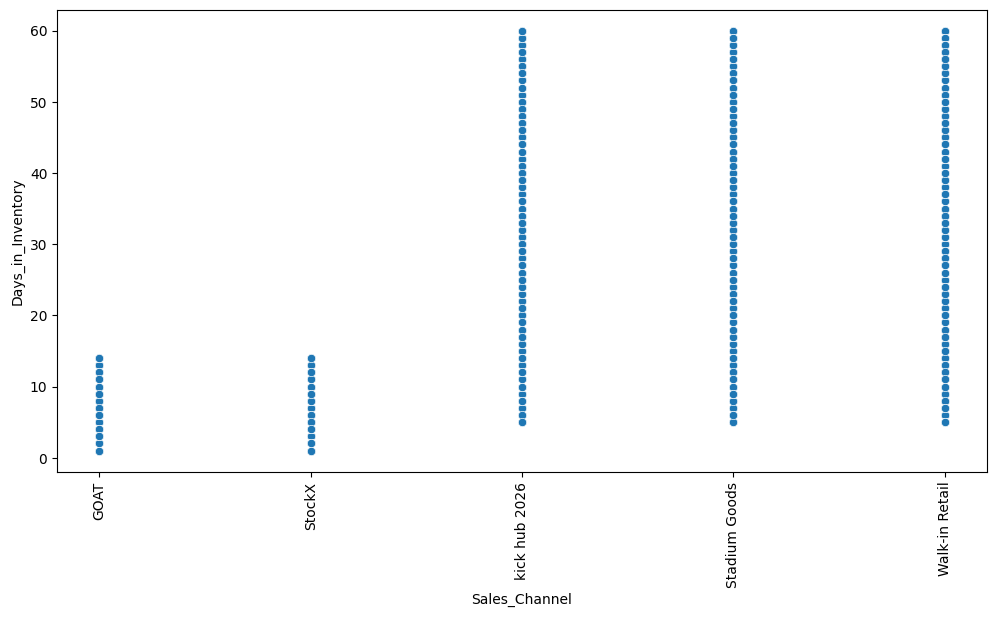

In [1060]:
plt.figure(figsize=(12,6))

sns.scatterplot(data=df, x='Sales_Channel', y='Days_in_Inventory')
plt.xticks(rotation=90)

**Observations**:
- **kick hub 2026**, **Stadium Goods** & **Walk-in Retail** : all these platforms have same number of max Inventory Days for the shoes i.e., max 60 days 
- Whereas **GOAT** and **StockX** both had shoes for a maximum of 15 days in their inventory
- Also **GOAT** and **StockX** are the platforms that moved inventory the fastest (1 day) as compared to 5 days (minimum for rest) for the rest of the platforms
- Minimum inventory days for **GOAT** & **StockX** = 1 day 
- Minimum inventory days for **kick hub 2026**, **Stadium Goods** & **Walk-in Retail** = 5 days 


In [1061]:
df.columns 

Index(['Transaction_ID', 'Sale_Date', 'Shoe_Model', 'Colorway', 'Condition',
       'Retail_Price_USD', 'Resale_Price_USD', 'Sales_Channel',
       'Days_in_Inventory', 'Profit_Margin_USD'],
      dtype='object')

Converting DataFrame to Date Time format so that we can apply Date Related Operations:

In [1062]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

Extracting Year:

In [1063]:
df['Year'] = df['Sale_Date'].dt.year
df['Year']

0       2024
1       2023
2       2023
3       2024
4       2023
        ... 
4995    2023
4996    2023
4997    2024
4998    2024
4999    2024
Name: Year, Length: 5000, dtype: int32

In [1064]:
df['Sale_Date'].dt.year.unique()

array([2024, 2023, 2025], dtype=int32)

In [1065]:
df.columns

Index(['Transaction_ID', 'Sale_Date', 'Shoe_Model', 'Colorway', 'Condition',
       'Retail_Price_USD', 'Resale_Price_USD', 'Sales_Channel',
       'Days_in_Inventory', 'Profit_Margin_USD', 'Year'],
      dtype='object')

Visualizing Relation between Shoe Model & Profit Margin using Year as Color Indicator, Condition as Size Indicator and alpha for transparency:

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Air Jordan 11 Retro'),
  Text(1, 0, 'Air Jordan 1 High'),
  Text(2, 0, 'Air Jordan 4 Retro'),
  Text(3, 0, 'Air Jordan 1 Low'),
  Text(4, 0, 'Air Jordan 3 Retro')])

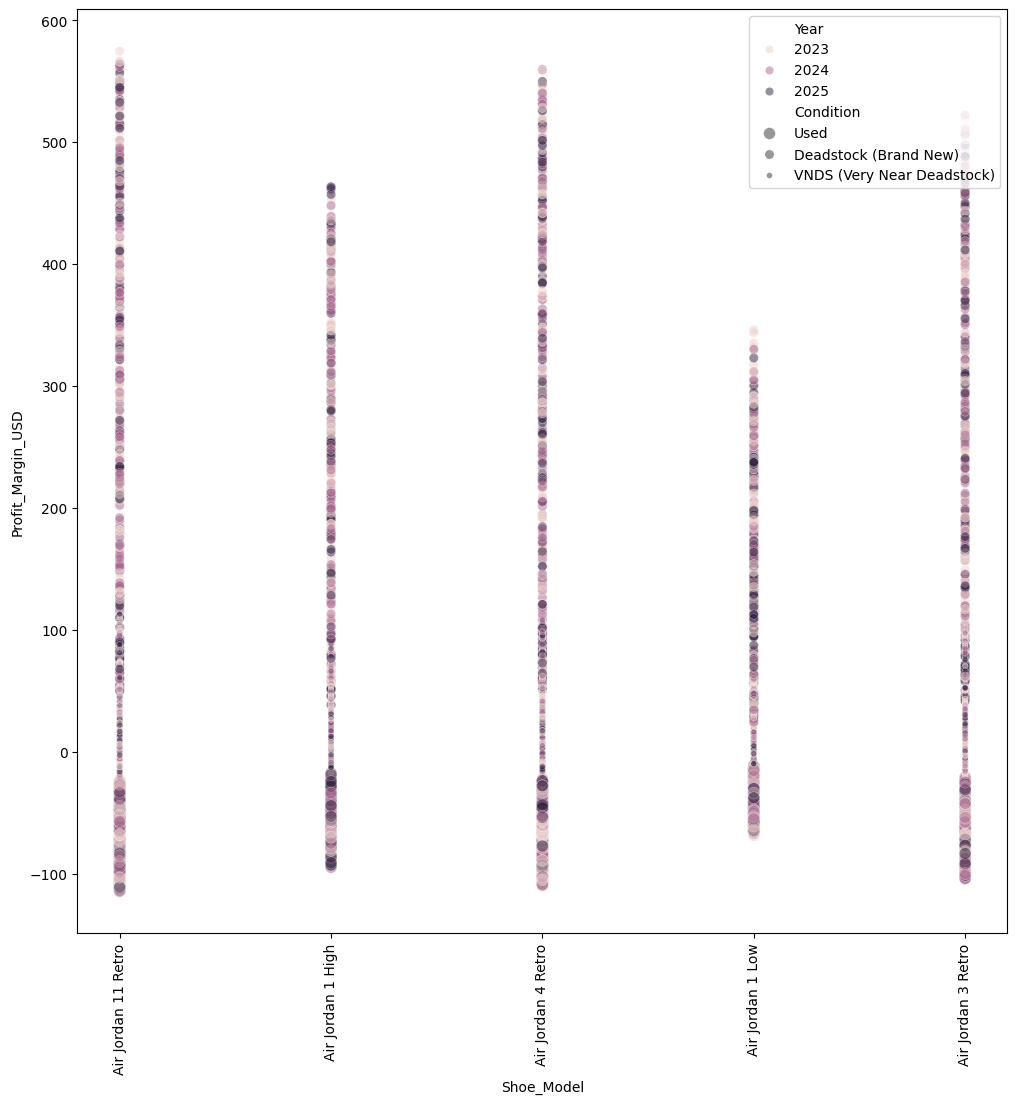

In [1066]:
plt.figure(figsize=(12,12))
sns.scatterplot(data=df, x='Shoe_Model', y='Profit_Margin_USD', hue='Year', size='Condition', alpha=0.5)
plt.xticks(rotation=90)

Observations:
- Presence of most bigger circles at bottom suggest that Profit Margin on Used shoes were by far the lowest
- Most Medium-sized circles are at Upper portions suggesting that Brand New shoes gave the most profits compared to VNDS & Used

([0, 1, 2, 3, 4],
 [Text(0, 0, 'GOAT'),
  Text(1, 0, 'StockX'),
  Text(2, 0, 'kick hub 2026'),
  Text(3, 0, 'Stadium Goods'),
  Text(4, 0, 'Walk-in Retail')])

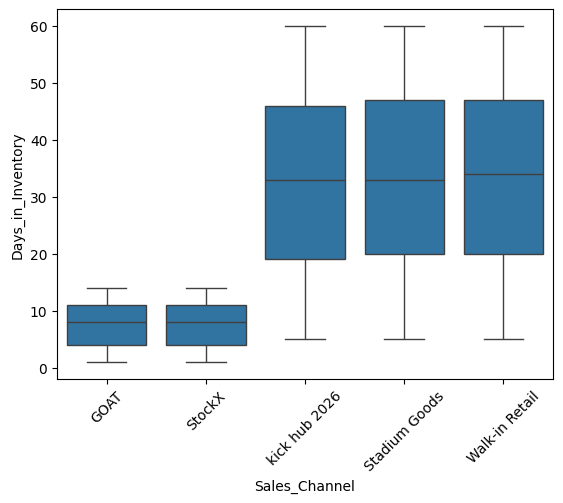

In [1067]:
sns.boxplot(data=df, x='Sales_Channel', y='Days_in_Inventory')
plt.xticks(rotation=45)

Clealy, this boxplot shows that:
- GOAT and StockX are the best sales channel as they have the lowest days in inventory counts ie they are better in selling products

In [1068]:
df['Shoe_Model'].unique()

array(['Air Jordan 11 Retro', 'Air Jordan 1 High', 'Air Jordan 4 Retro',
       'Air Jordan 1 Low', 'Air Jordan 3 Retro'], dtype=object)

Checking if 'Colorway' feature is a Strong Feature or not:

In [1069]:
df.groupby('Colorway')['Resale_Price_USD'].agg(['mean', 'std'])

,mean,std
Colorway,,
Black Cat,261.639946,163.187704
Bred,267.431734,158.932390
Chicago,276.332713,168.447908
Concord,272.057331,161.876588
Lost & Found,276.938188,171.895767
Military Blue,279.829313,170.961433
Mocha,272.450748,168.827742
Pine Green,278.385742,176.671863
Sail,273.608120,163.305767


- As the values in both mean and std are not fluctuating heavily
- Means, Colorway is not a strong feature for predicting Resale_Price
- So we are going to drop this feature

Checking if 'Condition' feature is a Strong Feature or not:

In [1070]:
df.groupby('Condition')['Resale_Price_USD'].agg(['mean', 'std'])

,mean,std
Condition,,
Deadstock (Brand New),455.507235,156.606747
Used,132.129444,33.718811
VNDS (Very Near Deadstock),229.836347,54.586520


- Values in mean & std are fluctuating heavily
- So, Condition is a Important Feature
- So we are not going to drop this feature

Checking if 'Sales_Channel' feature is a Strong Feature or not (Worthy to include in Model or not):

In [1071]:
df.groupby('Sales_Channel')['Resale_Price_USD'].agg(['mean', 'std'])

,mean,std
Sales_Channel,,
GOAT,276.542655,168.609286
Stadium Goods,272.612525,168.781032
StockX,265.440136,160.612599
Walk-in Retail,281.205005,169.130843
kick hub 2026,270.360322,169.025158


- As the values in both mean and std are not fluctuating heavily
- Means, Sales_Channel is not a strong feature for predicting Resale_Price
- So we are going to drop this feature

Average Profit Margin for Air jordan 11 retro:

In [1072]:
Jordan11 = df[df['Shoe_Model'] == 'Air Jordan 11 Retro']
Jordan11['Profit_Margin_USD'].mean()

99.83636176772868

Calculating Average Profit Margin for each Shoe Model using loop:

In [1073]:
shoe_model = ['Air Jordan 11 Retro', 'Air Jordan 1 High', 'Air Jordan 4 Retro', 'Air Jordan 1 Low', 'Air Jordan 3 Retro']

for shoe in shoe_model:
    shoe_df = df[df['Shoe_Model'] == shoe]
    print(f'Mean Profit Margin of {shoe}: {shoe_df['Profit_Margin_USD'].mean()}')
    print('---')

Mean Profit Margin of Air Jordan 11 Retro: 99.83636176772868
---
Mean Profit Margin of Air Jordan 1 High: 81.84961123110152
---
Mean Profit Margin of Air Jordan 4 Retro: 95.76080459770115
---
Mean Profit Margin of Air Jordan 1 Low: 50.521382352941174
---
Mean Profit Margin of Air Jordan 3 Retro: 82.78780135004821
---


Appending all info in list and then converting it to a dataframe:

In [1074]:
data_list = []
for shoe in shoe_model:
    shoe_df = df[df['Shoe_Model'] == shoe]
    shoe_data = {
        'Name': shoe,
        'Mean_Profit_Margin': shoe_df['Profit_Margin_USD'].mean()
    }
    data_list.append(shoe_data)
shoe_data = pd.DataFrame(data_list)
shoe_data

,Name,Mean_Profit_Margin
0,Air Jordan 11 Retro,99.836362
1,Air Jordan 1 High,81.849611
2,Air Jordan 4 Retro,95.760805
3,Air Jordan 1 Low,50.521382
4,Air Jordan 3 Retro,82.787801


Visualizing Profit Margin of each shoe model:

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Air Jordan 11 Retro'),
  Text(1, 0, 'Air Jordan 1 High'),
  Text(2, 0, 'Air Jordan 4 Retro'),
  Text(3, 0, 'Air Jordan 1 Low'),
  Text(4, 0, 'Air Jordan 3 Retro')])

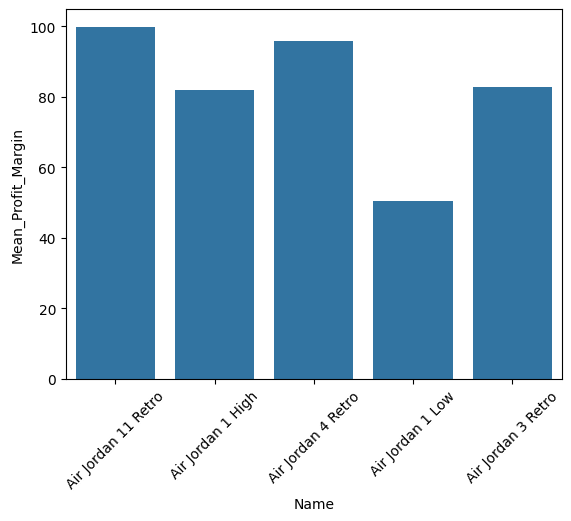

In [1075]:
sns.barplot(data=shoe_data, x='Name', y='Mean_Profit_Margin')
plt.xticks(rotation=45)

### Observations:
- Mean Profit Margin was Highest for = Air Jordan 11 Retro at 100
- Mean Profit Margin was Lowest for = Air Jordan 1 Low at ~50

In [1076]:
df.columns

Index(['Transaction_ID', 'Sale_Date', 'Shoe_Model', 'Colorway', 'Condition',
       'Retail_Price_USD', 'Resale_Price_USD', 'Sales_Channel',
       'Days_in_Inventory', 'Profit_Margin_USD', 'Year'],
      dtype='object')

Finding the features that matter for prediciting Resale Price using Correlation Matrix & HeatMap:

In [1077]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,Retail_Price_USD,Resale_Price_USD,Days_in_Inventory,Profit_Margin_USD,Year
Retail_Price_USD,1.000000,0.325609,-0.023327,0.109100,-0.029163
Resale_Price_USD,0.325609,1.000000,0.007123,0.975385,0.001646
Days_in_Inventory,-0.023327,0.007123,1.000000,0.012929,0.007455
Profit_Margin_USD,0.109100,0.975385,0.012929,1.000000,0.008532
Year,-0.029163,0.001646,0.007455,0.008532,1.000000


<Axes: >

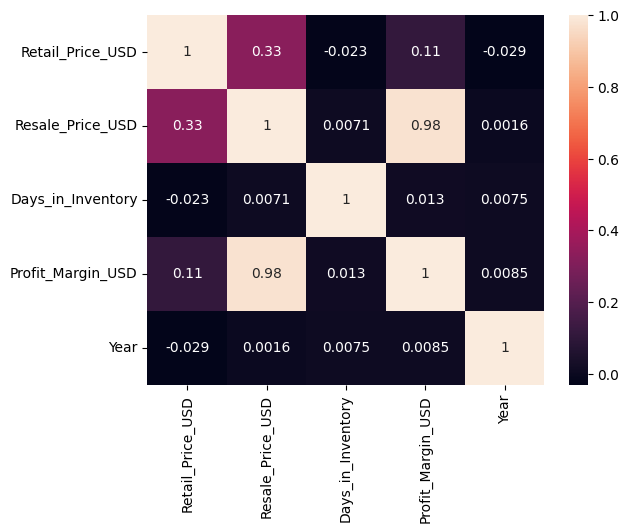

In [1078]:
sns.heatmap(data=corr_matrix, annot=True)

Therefore, feature that are useful are:
- **shoe_model**
- **condition** 
- **retail price**

### Encoding:

- Use **One-hot Encoding** for ColorWay as it is not in a specific order
- Use **Ordinal Encoding** for Condition as it is in a specific order

One-Hot Encoding:

In [1079]:
df = pd.get_dummies(data=df, columns=['Shoe_Model'], dtype=int)
df

,Transaction_ID,Sale_Date,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD,Year,Shoe_Model_Air Jordan 1 High,Shoe_Model_Air Jordan 1 Low,Shoe_Model_Air Jordan 11 Retro,Shoe_Model_Air Jordan 3 Retro,Shoe_Model_Air Jordan 4 Retro
0,TRX-100001,2024-10-23,Sail,Used,225,194.67,GOAT,13,-30.33,2024,0,0,1,0,0
1,TRX-100002,2023-10-23,Mocha,Deadstock (Brand New),185,230.46,StockX,10,45.46,2023,1,0,0,0,0
2,TRX-100003,2023-11-13,Concord,Deadstock (Brand New),212,270.37,kick hub 2026,33,58.37,2023,0,0,0,0,1
3,TRX-100004,2024-02-01,Mocha,Used,223,180.43,Stadium Goods,60,-42.57,2024,0,0,0,0,1
4,TRX-100005,2023-05-29,Mocha,Used,137,117.43,kick hub 2026,30,-19.57,2023,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TRX-104996,2023-02-17,Pine Green,Used,130,65.15,GOAT,11,-64.85,2023,0,1,0,0,0
4996,TRX-104997,2023-06-24,Chicago,Deadstock (Brand New),114,268.05,GOAT,9,154.05,2023,0,1,0,0,0
4997,TRX-104998,2024-06-12,Lost & Found,Deadstock (Brand New),222,405.55,StockX,9,183.55,2024,0,0,0,0,1
4998,TRX-104999,2024-06-19,Black Cat,Used,171,137.27,Walk-in Retail,24,-33.73,2024,1,0,0,0,0


Ordinal Encoding:

In [1080]:
df['Condition']=df['Condition'].map({'Deadstock (Brand New)':0, 'VNDS (Very Near Deadstock)':1, 'Used':2})
df

,Transaction_ID,Sale_Date,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD,Year,Shoe_Model_Air Jordan 1 High,Shoe_Model_Air Jordan 1 Low,Shoe_Model_Air Jordan 11 Retro,Shoe_Model_Air Jordan 3 Retro,Shoe_Model_Air Jordan 4 Retro
0,TRX-100001,2024-10-23,Sail,2,225,194.67,GOAT,13,-30.33,2024,0,0,1,0,0
1,TRX-100002,2023-10-23,Mocha,0,185,230.46,StockX,10,45.46,2023,1,0,0,0,0
2,TRX-100003,2023-11-13,Concord,0,212,270.37,kick hub 2026,33,58.37,2023,0,0,0,0,1
3,TRX-100004,2024-02-01,Mocha,2,223,180.43,Stadium Goods,60,-42.57,2024,0,0,0,0,1
4,TRX-100005,2023-05-29,Mocha,2,137,117.43,kick hub 2026,30,-19.57,2023,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TRX-104996,2023-02-17,Pine Green,2,130,65.15,GOAT,11,-64.85,2023,0,1,0,0,0
4996,TRX-104997,2023-06-24,Chicago,0,114,268.05,GOAT,9,154.05,2023,0,1,0,0,0
4997,TRX-104998,2024-06-12,Lost & Found,0,222,405.55,StockX,9,183.55,2024,0,0,0,0,1
4998,TRX-104999,2024-06-19,Black Cat,2,171,137.27,Walk-in Retail,24,-33.73,2024,1,0,0,0,0


## **Building The ML Model**:
Objective: Predict a shoe's **Resale_Price_USD** based on its **Colorway** & **Condition**

In [1081]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [1082]:
df.columns

Index(['Transaction_ID', 'Sale_Date', 'Colorway', 'Condition',
       'Retail_Price_USD', 'Resale_Price_USD', 'Sales_Channel',
       'Days_in_Inventory', 'Profit_Margin_USD', 'Year',
       'Shoe_Model_Air Jordan 1 High', 'Shoe_Model_Air Jordan 1 Low',
       'Shoe_Model_Air Jordan 11 Retro', 'Shoe_Model_Air Jordan 3 Retro',
       'Shoe_Model_Air Jordan 4 Retro'],
      dtype='object')

Defining X(Features) and y(Target) variables:

In [1083]:
X = df.drop(['Transaction_ID', 'Sale_Date', 'Days_in_Inventory', 'Profit_Margin_USD', 'Year', 'Resale_Price_USD', 'Colorway', 'Sales_Channel'], axis=1)
y = df['Resale_Price_USD']

In [1084]:
X

,Condition,Retail_Price_USD,Shoe_Model_Air Jordan 1 High,Shoe_Model_Air Jordan 1 Low,Shoe_Model_Air Jordan 11 Retro,Shoe_Model_Air Jordan 3 Retro,Shoe_Model_Air Jordan 4 Retro
0,2,225,0,0,1,0,0
1,0,185,1,0,0,0,0
2,0,212,0,0,0,0,1
3,2,223,0,0,0,0,1
4,2,137,0,1,0,0,0
...,...,...,...,...,...,...,...
4995,2,130,0,1,0,0,0
4996,0,114,0,1,0,0,0
4997,0,222,0,0,0,0,1
4998,2,171,1,0,0,0,0


In [1085]:
y

0       194.67
1       230.46
2       270.37
3       180.43
4       117.43
         ...  
4995     65.15
4996    268.05
4997    405.55
4998    137.27
4999    151.32
Name: Resale_Price_USD, Length: 5000, dtype: float64

Scaling the data:

In [1086]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(X)
X

array([[ 1.23045975,  0.91190623, -0.4767547 , ...,  2.03439085,
        -0.51153734, -0.51371484],
       [-1.21919136, -0.16639224,  2.09751473, ..., -0.49154763,
        -0.51153734, -0.51371484],
       [-1.21919136,  0.56145923, -0.4767547 , ..., -0.49154763,
        -0.51153734,  1.94660526],
       ...,
       [-1.21919136,  0.83103385, -0.4767547 , ..., -0.49154763,
        -0.51153734,  1.94660526],
       [ 1.23045975, -0.5437967 ,  2.09751473, ..., -0.49154763,
        -0.51153734, -0.51371484],
       [ 1.23045975,  0.372757  , -0.4767547 , ..., -0.49154763,
         1.9548915 , -0.51371484]])

Splitting the data:

In [1087]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training Models:

In [1088]:
lr = LinearRegression()

linear_model=lr.fit(X_train, y_train)
linear_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Linear Regression:

In [1105]:
y_lr_pred = linear_model.predict(X_test)
lr_r2 = r2_score(y_test, y_lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_lr_pred))

print(lr_r2)
print(lr_rmse)

0.7147969041046711
85.98520575854893


Lasso Regression:

In [ ]:
lasso = Lasso()

lasso_model = lasso.fit(X_train, y_train)
y_lasso_pred = lasso_model.predict(X_test)

lasso_r2 = r2_score(y_test, y_lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_lasso_pred))
print(lasso_r2)
print(lasso_rmse)

0.7154299773723374
85.88972086160456


Ridge Regression:

In [ ]:
ridge = Ridge()

ridge_model = ridge.fit(X_train, y_train)
y_ridge_pred = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, y_ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_ridge_pred))
print(ridge_r2)
print(ridge_rmse)

0.7148085492687257
85.98345030416726


RandomForestRegressor:
- Using this as it is a Non-linear regression model as compared to Linear, Lasso, Ridge Regression models which are all Linear models and cannot perform well if there is non-linear relationship between features

In [ ]:
rfr = RandomForestRegressor()

rfr_model = rfr.fit(X_train, y_train)
rfr_pred = rfr.predict(X_test)

rfr_r2 = r2_score(y_test, rfr_pred)
rfr_rmse = np.sqrt(mean_squared_error(y_test, rfr_pred))
print(rfr_r2)
print(rfr_rmse)

0.7545237876464497
79.77215490132059


HyperParameter Tuning:

Parameter Grid:

In [1093]:
param_grid_lr = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'fit_intercept': [True, False],
    'max_iter': [1000, 5000, 10000]
}


Using GridSearchCV:

In [1094]:
gs_lin = GridSearchCV(LinearRegression(), param_grid=param_grid_lr, scoring='r2', cv=5)
gs_lasso = GridSearchCV(Lasso(), param_grid=param_grid_lasso, scoring='r2', cv=5)
gs_ridge = GridSearchCV(Ridge(), param_grid=param_grid_ridge, scoring='r2', cv=5)

Linear Regression with GridSearchCV:

In [1100]:
gs_lin.fit(X_train, y_train),
gs_lin_best=gs_lin.best_estimator_.predict(X_test)
print(r2_score(y_test, gs_lin_best))
print(np.sqrt(mean_squared_error(y_test, gs_lin_best)))

0.7147969041046711
85.98520575854893


Lasso Regression with GridSearchCV:

In [1103]:
gs_lasso.fit(X_train, y_train)
gs_lasso_best=gs_lasso.best_estimator_.predict(X_test)
print(r2_score(y_test, gs_lasso_best))
print(np.sqrt(mean_squared_error(y_test, gs_lasso_best)))

/home/vinayakgaur07/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.678e+05, tolerance: 8.871e+03
  model = cd_fast.enet_coordinate_descent(
/home/vinayakgaur07/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.710e+05, tolerance: 9.047e+03
  model = cd_fast.enet_coordinate_descent(
/home/vinayakgaur07/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularis

0.7154299773723374
85.88972086160456


Ridge Regression with GridSearchCV:

In [1102]:
gs_ridge.fit(X_train, y_train)
gs_ridge_best=gs_ridge.best_estimator_.predict(X_test)
print(r2_score(y_test, gs_ridge_best))
print(np.sqrt(mean_squared_error(y_test, gs_ridge_best)))

0.714808549268726
85.98345030416722


## Conclusion:

In [1111]:
result = {
    'Name Of Models':['Linear Regression', 'Lasso Regression', 'Ridge Regression', 'RandomForest Regressor'],
    'R2 Scores': [lr_r2, lasso_r2, ridge_r2, rfr_r2],
    'RMSE Scores': [lr_rmse, lasso_rmse, ridge_rmse, rfr_rmse]
}

result_df = pd.DataFrame(result)
result_df

,Name Of Models,R2 Scores,RMSE Scores
0,Linear Regression,0.714797,85.985206
1,Lasso Regression,0.715430,85.889721
2,Ridge Regression,0.714809,85.983450
3,RandomForest Regressor,0.754524,79.772155


- Among the tested regression models, Random Forest performed the best with an R² score of **0.728** and RMSE Score of **83.91**
- However, the improvement over linear models is modest, suggesting that the relation between features is not purely linear and involves some Non-Linearity
- Performance is Limited, due to lack of market demand and trend data